# Notebook 5: Build training datasets

This is the fifth notebook in the sequence for the HRS Botany project.

In it we will build training datasets using EnMAP image hyperspectral bands as features and species-specific presesence/absence values as targets. There will be one training dataset with columns for each hyperspectral band and one column per species P/A. The dataset will consist of one row per pixel, and will also contain plot / enmap image id information.


__Notebook Inputs:__
- Gridded Species Presence-Absence geojsons by EnMAP Pixel  (_data/output_tables/{plot_id}/{enmap_image_id}/presence_absence.geojson_)
- Trimmed EnMAP tiffs and sidecar metadata JSONs 

__Notebook Outputs:__
- Hyperspectral Bands + Species P/A Training Dataset  (_data/output_tables/{plot_id}/{enmap_image_id}/counts.geojson_)


In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

from hrs_botany.dataset_builder import EnmapDatasetBuilder

In [2]:
enmap_dir = "./data/enmap_downloads/enmap_downloads_20250708"
pa_root = "./data/output_tables/20250809"
output_path = "./data/training_data/training_dataset_20250809.parquet"



builder = EnmapDatasetBuilder(
    enmap_root=enmap_dir,
    pa_root=pa_root,
    band_indices=None,          # all bands
    use_only_valid=True,        # only pixels fully/partially inside the plot (as flagged by gridder)
    min_coverage=0.0,           # keep any intersecting pixel (tune if needed)
    mask_value=-32768,          # convert nodata to NaN
    prefer_sample=True,
    verbose=True,
)
df = builder.build(output_path=output_path)


Scanning EnMAP root: data/enmap_downloads/enmap_downloads_20250708


Plots:   0%|          | 0/27 [00:00<?, ?it/s]

Plots:   7%|▋         | 2/27 [00:00<00:01, 12.72it/s]


Processing plot: 0112
  Scene: ENMAP01-____L2A-DT0000001029_20220609T193006Z_002_V010400_20231221T171725Z
    Files in scene dir: ['ENMAP01-____L2A-DT0000001029_20220609T193006Z_002_V010400_20231221T171725Z-SPECTRAL_IMAGE_COG.tiff', 'ENMAP01-____L2A-DT0000001029_20220609T193006Z_002_V010400_20231221T171725Z-SPECTRAL_IMAGE_COG.json']
    ▸ Dropped 8 all-NaN-species edge pixels
    ✅ Loaded 11 pixels for sampling
    ▸ Using TIFF nodata value for masking: -32768.0
  Scene: ENMAP01-____L2A-DT0000041496_20230911T193100Z_006_V010502_20250210T191823Z
    Files in scene dir: ['ENMAP01-____L2A-DT0000041496_20230911T193100Z_006_V010502_20250210T191823Z-SPECTRAL_IMAGE_COG.tiff', 'ENMAP01-____L2A-DT0000041496_20230911T193100Z_006_V010502_20250210T191823Z-SPECTRAL_IMAGE_COG.json']
    ▸ Dropped 8 all-NaN-species edge pixels
    ✅ Loaded 11 pixels for sampling
    ▸ Using TIFF nodata value for masking: -32768.0

Processing plot: 0115
  Scene: ENMAP01-____L2A-DT0000015023_20230429T193017Z_002_V0104

Plots:  15%|█▍        | 4/27 [00:00<00:06,  3.74it/s]

...

  Scene: ENMAP01-____L2A-DT0000101230_20241104T191929Z_009_V010501_20241113T041107Z
    Files in scene dir: ['ENMAP01-____L2A-DT0000101230_20241104T191929Z_009_V010501_20241113T041107Z-SPECTRAL_IMAGE_COG.tiff', 'ENMAP01-____L2A-DT0000101230_20241104T191929Z_009_V010501_20241113T041107Z-SPECTRAL_IMAGE_COG.json']
    ▸ Dropped 3 all-NaN-species edge pixels
    ✅ Loaded 53 pixels for sampling
    ▸ Using TIFF nodata value for masking: -32768.0

Processing plot: 0076
  Scene: ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010303_20230922T224955Z
    Files in scene dir: ['ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010303_20230922T224955Z-SPECTRAL_IMAGE_COG.tiff', 'ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010303_20230922T224955Z-SPECTRAL_IMAGE_COG.json']
    ▸ Dropped 5 all-NaN-species edge pixels
    ✅ Loaded 32 pixels for sampling
    ▸ Using TIFF nodata value for masking: -32768.0
  Scene: ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010400_20240107T000826Z
   

Plots:  96%|█████████▋| 26/27 [00:03<00:00,  7.79it/s]

  Scene: ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010400_20240107T000826Z
    Files in scene dir: ['ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010400_20240107T000826Z-SPECTRAL_IMAGE_COG.tiff', 'ENMAP01-____L2A-DT0000001376_20220628T192312Z_016_V010400_20240107T000826Z-SPECTRAL_IMAGE_COG.json']
    ▸ Dropped 11 all-NaN-species edge pixels
    ✅ Loaded 43 pixels for sampling
    ▸ Using TIFF nodata value for masking: -32768.0
  Scene: ENMAP01-____L2A-DT0000028166_20230709T064108Z_002_V010402_20240724T202501Z
    Files in scene dir: ['ENMAP01-____L2A-DT0000028166_20230709T064108Z_002_V010402_20240724T202501Z-SPECTRAL_IMAGE_COG.tiff', 'ENMAP01-____L2A-DT0000028166_20230709T064108Z_002_V010402_20240724T202501Z-SPECTRAL_IMAGE_COG.json']
    ▸ Dropped 11 all-NaN-species edge pixels
    ✅ Loaded 43 pixels for sampling
    ▸ Using TIFF nodata value for masking: -32768.0

Processing plot: f1
  Scene: ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z
   

Plots: 100%|██████████| 27/27 [00:04<00:00,  6.73it/s]


✅ Total pixels added: 3546


In [3]:
# from tqdm import tqdm
# import geopandas as gpd
# import pandas as pd
# import rasterio
# from pathlib import Path
# import numpy as np
# import json

# def load_enmap_band_values(tiff_path, pixel_geom, band_indices=None):
#     with rasterio.open(tiff_path) as src:
#         if band_indices is None:
#             band_indices = list(range(1, src.count + 1))  # 1-based indexing
#         centroid = pixel_geom.centroid
#         row, col = src.index(centroid.x, centroid.y)
#         band_values = []
#         for i in band_indices:
#             band = src.read(i)
#             band_values.append(band[row, col])
#     return band_values

# def build_dataset(
#     enmap_root,
#     pa_root,
#     band_indices=None,
#     output_path=None,
# ):
#     all_rows = []
#     enmap_root = Path(enmap_root)
#     pa_root = Path(pa_root)

#     print(f"Scanning EnMAP root: {enmap_root}")
#     for plot_dir in tqdm(list(enmap_root.iterdir()), desc="Plot directories"):
#         if not plot_dir.is_dir():
#             continue
#         plot_id = plot_dir.name
#         print(f"\nProcessing plot: {plot_id}")

#         for scene_dir in plot_dir.iterdir():
#             scene_id = scene_dir.name
#             print(f"  Scene: {scene_id}")
#             print(f"    Files in scene dir: {[f.name for f in scene_dir.iterdir()]}")

#             # --- Find TIFF (case-insensitive, robust) ---
#             tiff_path = next(
#                 (f for f in scene_dir.iterdir()
#                 if "SPECTRAL_IMAGE_COG" in f.name and f.suffix.lower() == ".tiff"),
#                 None
#             )

#             # --- Find JSON (case-insensitive, robust) ---
#             json_path = next(
#                 (f for f in scene_dir.iterdir()
#                 if "SPECTRAL_IMAGE_COG" in f.name and f.suffix.lower() == ".json"),
#                 None
#             )

#             if not tiff_path or not json_path:
#                 print(f"    ⚠️ Missing TIFF or JSON in {scene_dir}")
#                 print(f"    → Found files: {[f.name for f in scene_dir.iterdir()]}")
#                 continue

#             pa_geojson = pa_root / plot_id / scene_id / "presence_absence.geojson"

#             if not tiff_path:
#                 print(f"    ⚠️ Missing TIFF in {scene_dir}")
#                 continue
#             if not json_path:
#                 print(f"    ⚠️ Missing JSON in {scene_dir}")
#                 continue
#             if not pa_geojson.exists():
#                 print(f"    ⚠️ Missing presence_absence.geojson: {pa_geojson}")
#                 continue

#             try:
#                 gdf = gpd.read_file(pa_geojson)
#                 gdf = gdf[gdf["valid_pixel"] == True].copy()
#                 print(f"    ✅ Loaded {len(gdf)} valid pixels")

#                 with open(json_path) as f:
#                     meta = json.load(f)

#                 for _, row in gdf.iterrows():
#                     pixel_geom = row.geometry
#                     enmap_values = load_enmap_band_values(tiff_path, pixel_geom, band_indices)

#                     pixel_data = {
#                         "plot_id": plot_id,
#                         "scene_id": scene_id,
#                         "pixel_id": row["pixel_id"],
#                         "row": row["row"],
#                         "col": row["col"],
#                         "centroid": row["centroid"],
#                     }

#                     # Add EnMAP band values
#                     for i, val in enumerate(enmap_values, 1):
#                         pixel_data[f"band_{i}"] = val

#                     # Add species columns
#                     species_cols = [k for k in row.index if k.isdigit()]
#                     for s in species_cols:
#                         pixel_data[s] = row[s]

#                     all_rows.append(pixel_data)

#             except Exception as e:
#                 print(f"    ❌ Error processing {scene_id}: {e}")
#                 continue

#     print(f"\n✅ Total pixels added: {len(all_rows)}")

#     df = pd.DataFrame(all_rows)

#     if not df.empty:
#         if output_path:
#             print(f"📁 Saving to {output_path}")
#             df.to_parquet(output_path, index=False)
#         else:
#             print("⚠️ No output path provided. Returning DataFrame only.")
#     else:
#         print("⚠️ No data found. Check warnings above.")

#     return df


In [4]:
# enmap_root="./data/enmap_downloads/enmap_downloads_20250708"
# pa_root="./data/output_tables"
# output_path = "./data/training_data/training_dataset.parquet"

# df = build_dataset(
#     enmap_root,
#     pa_root,
#     band_indices=None,
#     output_path=output_path,
# )

In [7]:
plot_59_df = df[df.plot_id == "0059"]

plot_59_df = plot_59_df.dropna(axis=1, how='all')

species_2685796_df = df.dropna(subset=['2685796'])


band_cols = [col for col in df.columns if col.startswith('band')]

cols_to_keep = ['plot_id', 'scene_id', 'pixel_id', 'row', 'col', 'centroid'] + band_cols + ['2685796']
number_cols = [col for col in species_2685796_df.columns if col[0].isdigit() and col != '2685796']
species_2685796_df_subset = species_2685796_df.drop(columns=number_cols)
species_2685796_df_subset = species_2685796_df_subset[cols_to_keep]
species_2685796_df_subset

,plot_id,scene_id,pixel_id,row,col,centroid,band_1,band_2,band_3,band_4,...,band_216,band_217,band_218,band_219,band_220,band_221,band_222,band_223,band_224,2685796
22,0115,ENMAP01-____L2A-DT0000015023_20230429T193017Z_...,0_0,0,0,POINT (702390 4308930),219.0,182.0,157.0,175.0,...,509.0,511.0,481.0,468.0,466.0,482.0,415.0,417.0,368.0,1.0
23,0115,ENMAP01-____L2A-DT0000015023_20230429T193017Z_...,0_1,0,1,POINT (702420 4308930),208.0,168.0,156.0,182.0,...,449.0,420.0,401.0,403.0,397.0,406.0,353.0,354.0,296.0,1.0
24,0115,ENMAP01-____L2A-DT0000015023_20230429T193017Z_...,0_2,0,2,POINT (702450 4308930),221.0,171.0,171.0,179.0,...,416.0,428.0,395.0,402.0,361.0,405.0,336.0,367.0,277.0,1.0
25,0115,ENMAP01-____L2A-DT0000015023_20230429T193017Z_...,0_3,0,3,POINT (702480 4308930),206.0,174.0,159.0,168.0,...,364.0,377.0,335.0,345.0,326.0,342.0,290.0,311.0,216.0,1.0
26,0115,ENMAP01-____L2A-DT0000015023_20230429T193017Z_...,1_0,1,0,POINT (702390 4308900),244.0,199.0,191.0,228.0,...,611.0,622.0,606.0,599.0,555.0,597.0,534.0,519.0,455.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3540,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,15_12,15,12,POINT (582660 4096590),112.0,70.0,46.0,106.0,...,229.0,249.0,204.0,227.0,192.0,195.0,148.0,160.0,108.0,1.0
3541,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,15_13,15,13,POINT (582690 4096590),145.0,70.0,57.0,83.0,...,203.0,241.0,193.0,197.0,191.0,187.0,141.0,182.0,107.0,1.0
3543,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,16_11,16,11,POINT (582630 4096560),147.0,122.0,90.0,131.0,...,429.0,427.0,412.0,410.0,392.0,372.0,322.0,319.0,264.0,1.0
3544,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,16_12,16,12,POINT (582660 4096560),113.0,68.0,55.0,91.0,...,229.0,253.0,232.0,244.0,214.0,206.0,163.0,167.0,143.0,1.0


In [8]:
df = pd.read_parquet(output_path)

In [9]:
plot_f1 = df.iloc[1]

Several spectral ranges were excluded due to strong water vapor absorption, including bands between 1330.86 and 1461.11 nm (with bands 131–135 already excluded from the source data) and between 1796 and 1938 nm.

In [13]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

def qa_scene_presence_map(pa_geojson_path, tiff_path, species_key, min_coverage=0.0):
    """
    Visual checks for one scene:
      A) Pixel map colored by status for the chosen species:
         - 1  => presence
         - 0  => true absence (full-pixel only)
         - NaN => thrown-out partial pixel with 0 stems
      B) Histogram of coverage_fraction
      C) Bar chart of counts by status (presence / absence / NaN)
    """
    pa_geojson_path = Path(pa_geojson_path)
    tiff_path = Path(tiff_path)

    gdf = gpd.read_file(pa_geojson_path)
    if species_key not in gdf.columns:
        raise ValueError(f"Species '{species_key}' not found in {pa_geojson_path}")

    # Optional coverage filter
    if "coverage_fraction" in gdf.columns and min_coverage > 0:
        gdf = gdf[gdf["coverage_fraction"] >= float(min_coverage)].copy()

    # Reproject to raster CRS if needed (defensive)
    with rasterio.open(tiff_path) as src:
        if gdf.crs and src.crs and gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)

        # Make 3 panels
        fig = plt.figure(figsize=(13, 4))
        ax_map = fig.add_subplot(1, 3, 1)
        ax_hist = fig.add_subplot(1, 3, 2)
        ax_bar = fig.add_subplot(1, 3, 3)

        # A) Map by status
        vals = gdf[species_key]
        status = pd.Series(np.where(vals.notna(), vals, np.nan), index=gdf.index).astype(float)
        # presence (1), absence (0, only full pixels), nan=thrown out
        gdf_status = gdf.copy()
        gdf_status["status"] = status

        # draw raster extent box lightly (no actual imagery for speed)
        ax_map.set_title(f"Pixel map — species {species_key}")
        gdf_status.plot(
            ax=ax_map,
            column="status",
            legend=True,
            edgecolor="k",
            linewidth=0.2,
            alpha=0.8,
        )
        ax_map.set_xlabel("x"); ax_map.set_ylabel("y")

        # B) Coverage histogram
        if "coverage_fraction" in gdf.columns:
            ax_hist.hist(gdf["coverage_fraction"].values, bins=20)
            ax_hist.set_title("coverage_fraction")
            ax_hist.set_xlabel("fraction"); ax_hist.set_ylabel("count")
        else:
            ax_hist.text(0.5, 0.5, "No coverage_fraction column", ha="center", va="center")
            ax_hist.set_axis_off()

        # C) Counts by status
        # three bins: presence (1), absence (0), thrown-out (NaN)
        n_presence = int((status == 1).sum())
        n_absence  = int((status == 0).sum())
        n_nan      = int(status.isna().sum())
        ax_bar.bar(["presence","absence","thrown-out"], [n_presence, n_absence, n_nan])
        ax_bar.set_title("Pixel counts by status")

        fig.suptitle(f"{pa_geojson_path.parent.name}", y=1.02)
        fig.tight_layout()
        return fig


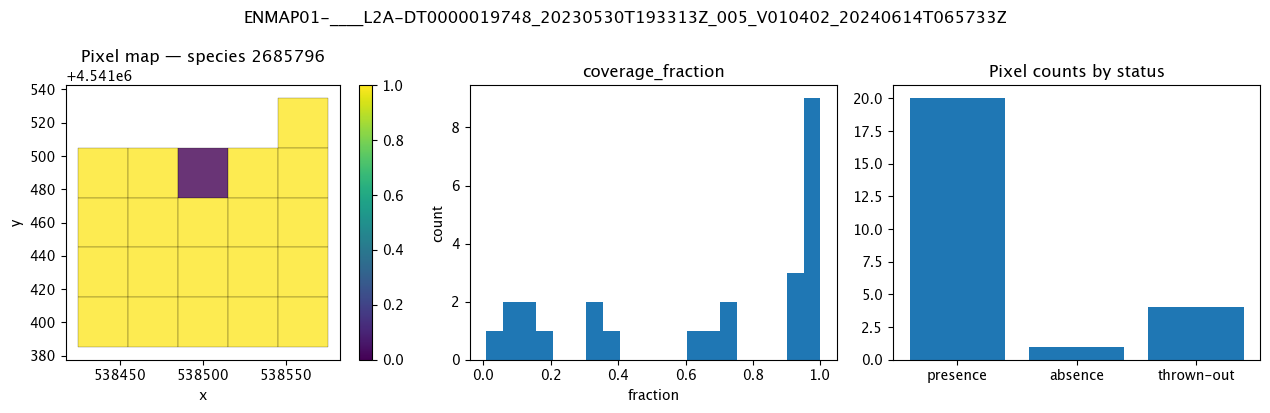

In [16]:
# example
fig = qa_scene_presence_map(
    "./data/output_tables/20250809/0063/ENMAP01-____L2A-DT0000019748_20230530T193313Z_005_V010402_20240614T065733Z/presence_absence.geojson",
    "./data/enmap_downloads/enmap_downloads_20250708/0063/ENMAP01-____L2A-DT0000019748_20230530T193313Z_005_V010402_20240614T065733Z/ENMAP01-____L2A-DT0000019748_20230530T193313Z_005_V010402_20240614T065733Z-SPECTRAL_IMAGE_COG.tiff",
    species_key="2685796",   # your GBIF key as string
    min_coverage=0.0
)


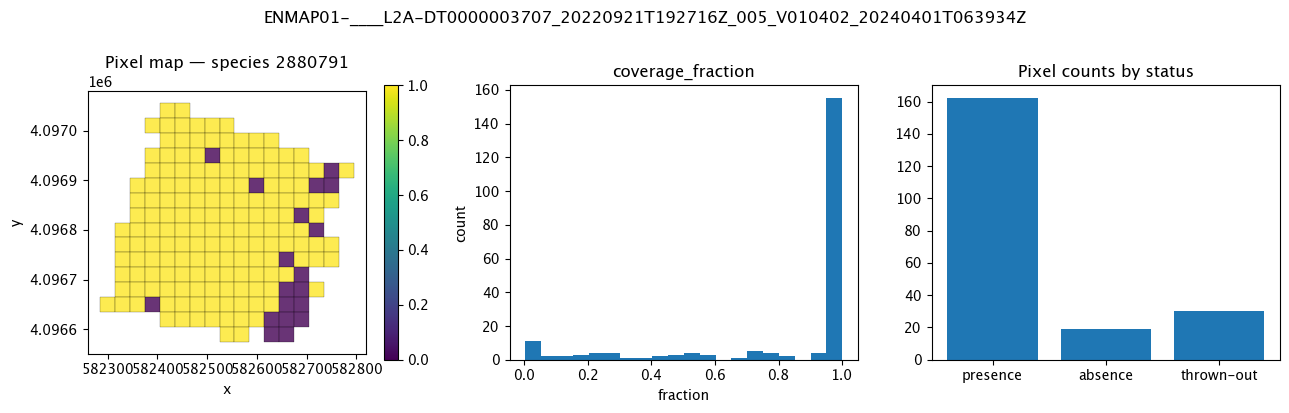

In [15]:
# example
fig = qa_scene_presence_map(
    "./data/output_tables/20250809/f1/ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z/presence_absence.geojson",
    "./data/enmap_downloads/enmap_downloads_20250708/f1/ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z/ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z-SPECTRAL_IMAGE_COG.tiff",
    species_key="2880791",   # your GBIF key as string
    min_coverage=0.0
)


In [22]:
f1_pa_geojson_path = './data/output_tables/20250809/f1/ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z/presence_absence.geojson'
f1_tiff_path = './data/enmap_downloads/enmap_downloads_20250708/f1/ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z/ENMAP01-____L2A-DT0000003707_20220921T192716Z_005_V010402_20240401T063934Z-SPECTRAL_IMAGE_COG.tiff'
f1_species_key = "2880791"  # your GBIF key as string


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def qa_dataset_parquet(parquet_path, species_key, band_for_scatter="band_50"):
    df = pd.read_parquet(parquet_path)
    if species_key not in df.columns:
        raise ValueError(f"Species '{species_key}' not found in dataset columns")

    fig_list = []

    # A) Class balance
    vals = df[species_key]
    n1 = int((vals == 1).sum())
    n0 = int((vals == 0).sum())
    nn = int(vals.isna().sum())

    fig1, ax1 = plt.subplots(figsize=(4,4))
    ax1.bar(["presence","absence","NaN"], [n1, n0, nn])
    ax1.set_title(f"{species_key}: class counts")
    fig_list.append(fig1)

    # B) Coverage histogram (if present)
    if "coverage_fraction" in df.columns:
        fig2, ax2 = plt.subplots(figsize=(5,4))
        ax2.hist(df["coverage_fraction"].dropna().values, bins=25)
        ax2.set_title("coverage_fraction (dataset)")
        ax2.set_xlabel("fraction")
        fig_list.append(fig2)

    # C) Simple diagnostic: band vs target (presence only / absence only)
    if band_for_scatter in df.columns:
        fig3, ax3 = plt.subplots(figsize=(5,4))
        present = df.loc[vals == 1, band_for_scatter].astype(float)
        absent  = df.loc[vals == 0, band_for_scatter].astype(float)
        ax3.scatter(np.arange(len(present)), present, s=10, label="presence")
        ax3.scatter(np.arange(len(absent)),  absent,  s=10, label="absence")
        ax3.set_title(f"{band_for_scatter} values by class")
        ax3.set_xlabel("index"); ax3.set_ylabel("reflectance")
        ax3.legend()
        fig_list.append(fig3)

    return fig_list


In [ ]:
enmap_dir = "./data/enmap_downloads/enmap_downloads_20250708"
pa_root = "./data/output_tables/20250809"
output_path = "./data/training_data/training_dataset_20250809.parquet"



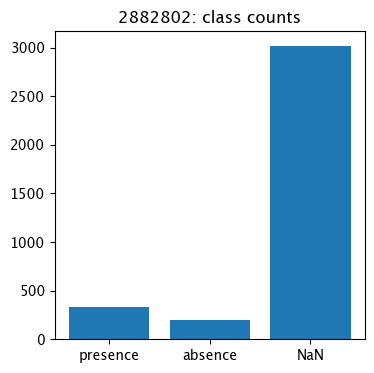

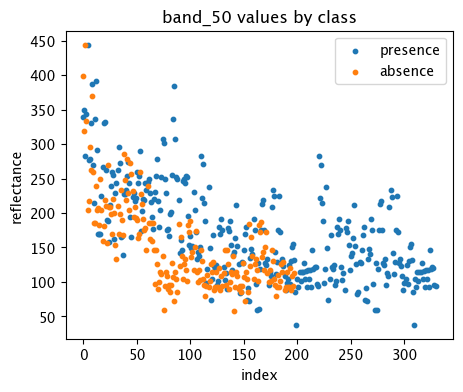

In [27]:
# After you run builder.build(output_path="…/enmap_dataset.parquet")
figs = qa_dataset_parquet(output_path, species_key="2882802", band_for_scatter="band_50")
# figs is a list of matplotlib figures; display "…/enmap_dataset.parquet"or save them as you like.


In [26]:
df

,plot_id,scene_id,pixel_id,row,col,centroid,band_1,band_2,band_3,band_4,...,2876032,2878124,2880791,2882802,3024146,3176787,3189835,5285497,5371727,6362957
0,0112,ENMAP01-____L2A-DT0000001029_20220609T193006Z_...,1_1,1,1,POINT (722820 4274700),145.0,140.0,148.0,157.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0112,ENMAP01-____L2A-DT0000001029_20220609T193006Z_...,1_2,1,2,POINT (722850 4274700),183.0,186.0,186.0,203.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0112,ENMAP01-____L2A-DT0000001029_20220609T193006Z_...,1_3,1,3,POINT (722880 4274700),177.0,172.0,181.0,209.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0112,ENMAP01-____L2A-DT0000001029_20220609T193006Z_...,2_1,2,1,POINT (722820 4274670),138.0,124.0,124.0,146.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0112,ENMAP01-____L2A-DT0000001029_20220609T193006Z_...,2_2,2,2,POINT (722850 4274670),142.0,134.0,135.0,167.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,15_13,15,13,POINT (582690 4096590),145.0,70.0,57.0,83.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3542,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,16_10,16,10,POINT (582600 4096560),242.0,193.0,196.0,234.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3543,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,16_11,16,11,POINT (582630 4096560),147.0,122.0,90.0,131.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3544,f1,ENMAP01-____L2A-DT0000007897_20230215T193730Z_...,16_12,16,12,POINT (582660 4096560),113.0,68.0,55.0,91.0,...,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
